### Bibliotecas e Frameworks

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow import keras

2025-09-01 23:33:16.268779: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-01 23:33:16.413759: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-01 23:33:18.567546: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Questão 1

Implemente uma rede perceptron de múltiplas camadas e utilize-a para aproximar as funções abaixo.  

a. f(x) = log10(x), onde 1 ≤ x ≤ 10

b. f(x) = 10x^5 + 5x^4 + 2x^3 – 0.5x^2 + 3x + 2, onde 0 ≤ x ≤ 5

Para cada função a ser aproximada, gere um conjunto de treinamento e um conjunto de testes. 

Nesses conjuntos, cada amostra deve ser representada da seguinte forma: x é a entrada e f(x) é a saída desejada - rótulo. Treine um perceptron de múltiplas camadas para que ele aprenda a aproximar a função a partir do conjunto de treinamento, e vá testando com o conjunto de validação.  

Apresente os gráficos das funções reais vs. funções aproximadas e as curvas de erro de treinamento e validação.

#### Item a)

In [2]:
# Data

f = lambda x: np.log10(x)
X = np.linspace(1, 10, 10000).reshape(-1, 1)
y = f(X)

X_max = max(X)
X_normalized = X/X_max

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_normalized, y, test_size=0.35, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

In [3]:
# Model

input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(100, activation="relu")(input_)
hidden2 = keras.layers.Dense(100, activation="relu")(hidden1)
hidden3 = keras.layers.Dense(100, activation="relu")(hidden2)
output = keras.layers.Dense(1, dtype="float64")(hidden3)

model = keras.Model(inputs=[input_], outputs=[output])
model.compile(loss="mse", optimizer="adam")
model.summary()

W0000 00:00:1756780399.849476  136282 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,501 (80.48 KB)

 Trainable params: 20,501 (80.48 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Train

history = model.fit(X_train, y_train, epochs=50, validation_data=(X_valid, y_valid))

# Prediction

y_pred = model.predict(X_test)

Epoch 1/50


2025-09-01 23:33:21.782029: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-09-01 23:33:21.842476: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0227 - val_loss: 0.0021
Epoch 2/50


2025-09-01 23:33:22.772510: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-09-01 23:33:22.801686: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.7715e-04 - val_loss: 2.9652e-04
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.8477e-04 - val_loss: 1.2278e-04
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.2392e-05 - val_loss: 8.5785e-05
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.1659e-05 - val_loss: 4.5633e-05
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4.2071e-05 - val_loss: 3.1220e-05
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.2097e-05 - val_loss: 2.1880e-05
Epoch 8/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.1342e-05 - val_loss: 1.8621e-05
Epoch 9/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.7364e-05 - val_loss: 1.6797e-05
Epoch 10/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.5988e-05 - val_loss: 1.4577e-05
Epoch 11/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2140e-05 - val_loss: 1.5058e-05
Epoch 12/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.1573e-

2025-09-01 23:33:49.739064: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-09-01 23:33:49.742647: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-09-01 23:33:49.895114: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-09-01 23:33:49.899895: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


<Figure size 640x480 with 0 Axes>

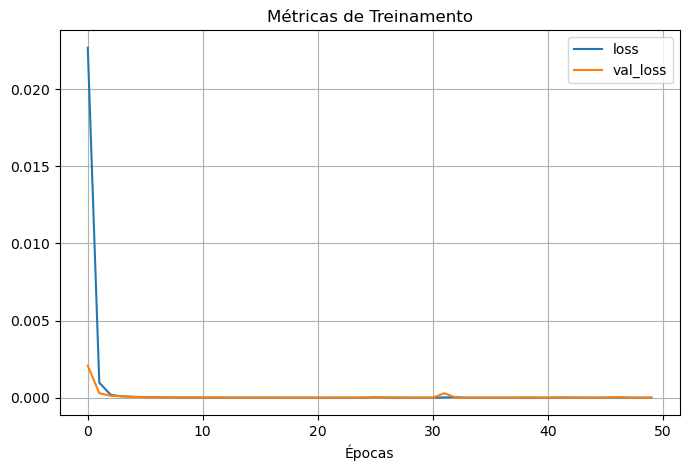

In [5]:
# Training Metrics

plt.figure()
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.title("Métricas de Treinamento")
plt.xlabel("Épocas")
plt.grid(True)
plt.show()

tf.Tensor(0.99992657, shape=(), dtype=float32)


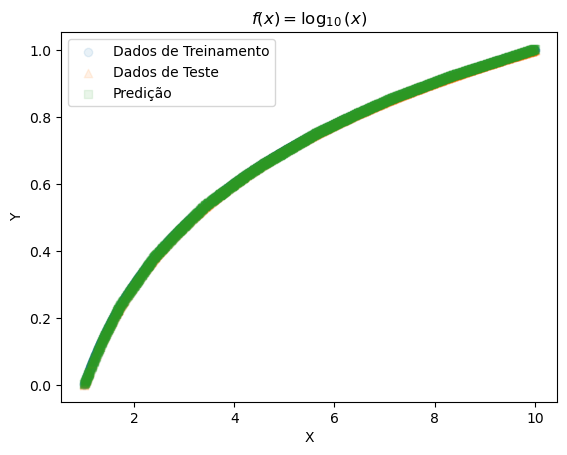

In [6]:
# Metrics

metric = keras.metrics.R2Score()
metric.update_state(y_test, y_pred)
result = metric.result()
print(result)

X_train_plot = X_train*X_max
X_test_plot = X_test*X_max

plt.figure()
plt.scatter(X_train_plot, y_train, alpha=0.1, label="Dados de Treinamento")
plt.scatter(X_test_plot, y_test, marker="^", alpha=0.1, label="Dados de Teste")
plt.scatter(X_test_plot, y_pred, marker="s", alpha=0.1, label="Predição")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title(r"$f(x) = \log _{10}(x)$");


#### Item b)

In [7]:
# Data

f = lambda x: 10*x**5 + 5*x**4 + 2*x**3 - 0.5*x**2 + 3*x + 2
X = np.linspace(0, 5, 10000).reshape(-1,1)
y = f(X)

X_max = max(X)
X_normalized = X/X_max
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_normalized, y, test_size=0.35, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

In [8]:
# Model

input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(100, activation="relu")(input_)
hidden2 = keras.layers.Dense(100, activation="relu")(hidden1)
hidden3 = keras.layers.Dense(100, activation="relu")(hidden2)
output = keras.layers.Dense(1, dtype="float64")(hidden3)

model = keras.Model(inputs=[input_], outputs=[output])
model.compile(loss="mse", optimizer="adam")
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,501 (80.48 KB)

 Trainable params: 20,501 (80.48 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train

history = model.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid))

# Prediction

y_pred = model.predict(X_test)

Epoch 1/100
 21/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 116390456.0000

2025-09-01 23:33:52.731297: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-09-01 23:33:52.800519: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 114079752.0000 - val_loss: 92896616.0000
Epoch 2/100
  1/163 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 70835136.0000

2025-09-01 23:33:53.497509: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-09-01 23:33:53.509920: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 73634688.0000 - val_loss: 53113784.0000
Epoch 3/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 54283448.0000 - val_loss: 46087888.0000
Epoch 4/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 46329764.0000 - val_loss: 37970224.0000
Epoch 5/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 37148512.0000 - val_loss: 29021878.0000
Epoch 6/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 27780124.0000 - val_loss: 20681872.0000
Epoch 7/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 19097448.0000 - val_loss: 13503138.0000
Epoch 8/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 12077210.0000 - val_loss: 8244985.5000
Epoch 9/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7242500.0000 - val_loss: 4929683.5000
Epoch 10/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4398510.5000 - val_loss: 2944447.0000
Epoch 11/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2775005.5000 - val_loss: 1878118.6250
Epoch 1

2025-09-01 23:34:55.079651: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-09-01 23:34:55.085431: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


2025-09-01 23:34:55.307638: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-09-01 23:34:55.314956: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


<Figure size 640x480 with 0 Axes>

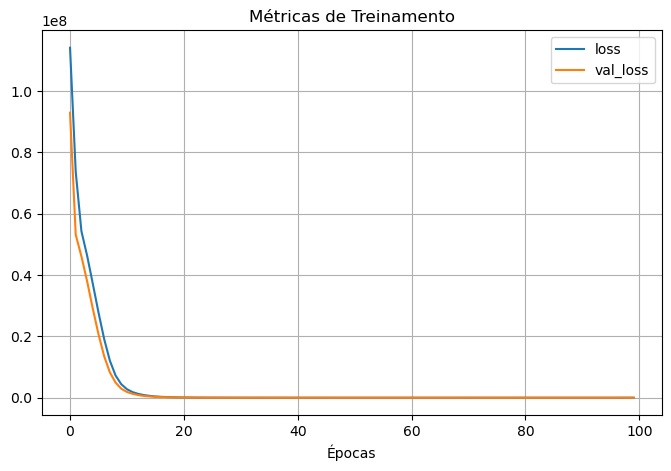

In [10]:
# Training Metrics

plt.figure()
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.title("Métricas de Treinamento")
plt.xlabel("Épocas")
plt.grid(True)
plt.show()

tf.Tensor(0.9999996, shape=(), dtype=float32)


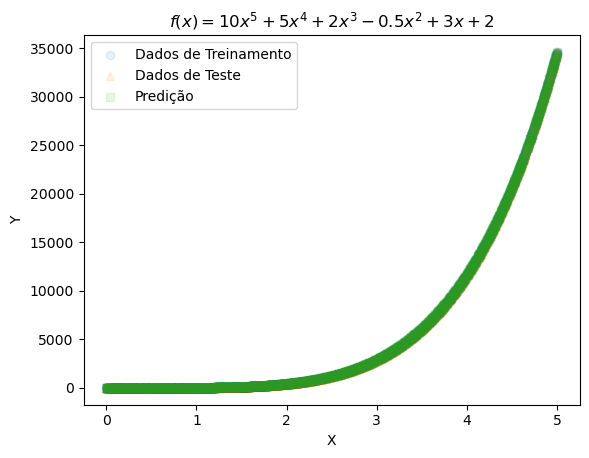

In [11]:
# Metrics

metric = keras.metrics.R2Score()
metric.update_state(y_test, y_pred)
result = metric.result()
print(result)

X_train_plot = X_train*X_max
X_test_plot = X_test*X_max

plt.figure()
plt.scatter(X_train_plot, y_train, alpha=0.1, label="Dados de Treinamento")
plt.scatter(X_test_plot, y_test, marker="^", alpha=0.1, label="Dados de Teste")
plt.scatter(X_test_plot, y_pred, marker="s", alpha=0.1, label="Predição")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title(r"$f(x) = 10x^5 + 5x^4 + 2x^3 - 0.5x^2 + 3x + 2$");